# Model improvement

## Dataset with Additional Categorical Features
Use the dataset containing both numerical and additional categorical features "df_final_all_features.csv" and compare it to the baseline. Log to MLflow.

**Dataset Alignment & Test Set Consistency**

Action:
Adapted the baseline dataset (df_final_num_cat.csv) to remove the 2 outlier rows (the "empty" targets) to perfectly match the advanced 44-feature dataset, and resaved it.

Machine Learning Rationale:
To accurately compare two models, they must be trained and evaluated on the exact same data splits. The aim of a train/test split is to estimate true model performance. To do this in an unbiased way, the test data needs to be independent of the training data. When row counts differ (even by just 2 rows), the random shuffle applied by train_test_split shifts entirely, resulting in mismatched test sets. This renders metrics like Mean Squared Error and R² mathematically incomparable. The test set provides an unbiased evaluation of how well the trained model generalizes to unseen data. By aligning the row counts, we guarantee a true, unbiased apples-to-apples performance evaluation.

In [ ]:
import pandas as pd

df_final_all = pd.read_csv("../data/processed/df_final_all_features.csv")

# 1. Define the baseline columns: numericals + ionizable dummy features + target
numerical_features = [
    "ionizable_ratio", 
    "helper_ratio", 
    "sterol_ratio", 
    "peg_ratio", 
    "particle_size_nm"
]

# Select dummy columns that start with 'ionizable_' (excluding the ratio column)
ionizable_dummy_cols = [
    col for col in df_final_all.columns 
    if col.startswith("ionizable_") and col != "ionizable_ratio"
]

target = "encapsulation_efficiency"

# 2. Slice the baseline DataFrame
baseline_columns = numerical_features + ionizable_dummy_cols + [target]
df_base_aligned = df_final_all[baseline_columns].copy()

# 3. Verify shape (should be 580 rows, 22 columns total: 21 features + 1 target)
print(f"Aligned baseline shape: {df_base_aligned.shape}")

# 4. Save the aligned baseline dataset
df_base_aligned.to_csv("../data/processed/df_final_num_cat.csv", index=False)
print("Aligned baseline dataset saved successfully!")

Aligned baseline shape: (580, 22)
Aligned baseline dataset saved successfully!


Tracking URI set to: sqlite:///C:\Users\irisb\CursorProjects\lnp-encapsulation-predictor\mlflow.db


c:\Users\irisb\CursorProjects\lnp-encapsulation-predictor\.venv\Lib\site-packages\mlflow\data\dataset_source_registry.py:148: UserWarning: The specified dataset source can be interpreted in multiple ways: LocalArtifactDatasetSource, LocalArtifactDatasetSource. MLflow will assume that this is a LocalArtifactDatasetSource source.
  return _dataset_source_registry.resolve(
c:\Users\irisb\CursorProjects\lnp-encapsulation-predictor\.venv\Lib\site-packages\mlflow\types\utils.py:440: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. 

Baseline Model - R2 Score: 0.5870 | MSE: 199.2569 | MAE: 9.8023


c:\Users\irisb\CursorProjects\lnp-encapsulation-predictor\.venv\Lib\site-packages\mlflow\data\dataset_source_registry.py:148: UserWarning: The specified dataset source can be interpreted in multiple ways: LocalArtifactDatasetSource, LocalArtifactDatasetSource. MLflow will assume that this is a LocalArtifactDatasetSource source.
  return _dataset_source_registry.resolve(
c:\Users\irisb\CursorProjects\lnp-encapsulation-predictor\.venv\Lib\site-packages\mlflow\types\utils.py:440: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. 

Advanced Model - R2 Score: 0.6009 | MSE: 192.5287 | MAE: 9.0780


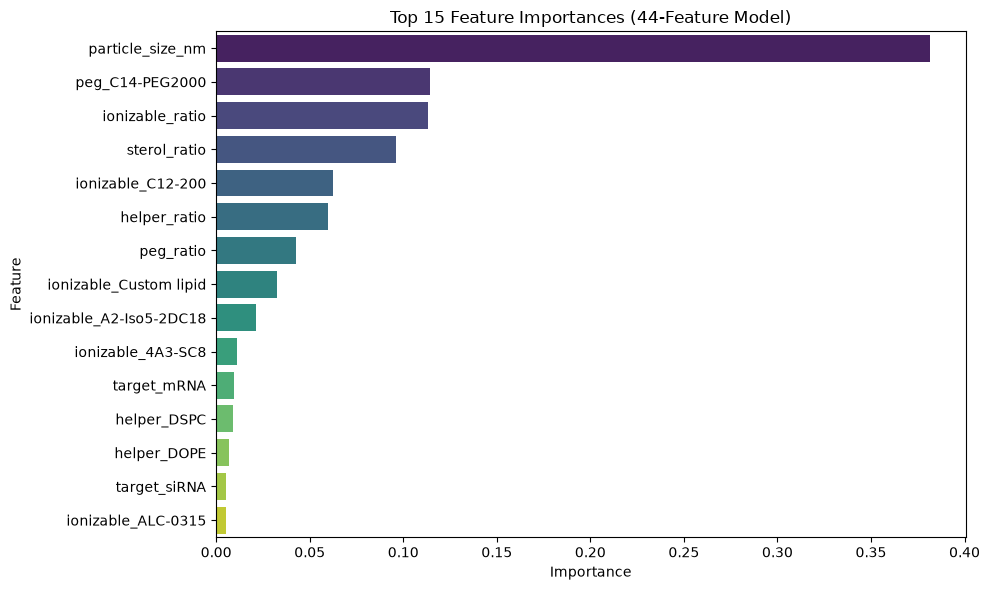

In [9]:
import os
import pathlib
import pandas as pd
import mlflow
import mlflow.sklearn
from mlflow.models import infer_signature
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# MLflow Setup
# Point reliably to mlflow.db in the project root
# (Finds the parent directory of the current 'notebooks' folder)
project_root = pathlib.Path().resolve().parent
db_path = project_root / "mlflow.db"
mlflow.set_tracking_uri(f"sqlite:///{db_path}")  #use SQLite database
mlflow.set_experiment("LNP_Encapsulation_Optimization")

print(f"Tracking URI set to: sqlite:///{db_path}")

# ==========================================
# MODEL 1: THE BASELINE (Fewer Features)
# ==========================================
df_base = pd.read_csv("../data/processed/df_final_num_cat.csv") 
X_base = df_base.drop(columns=["encapsulation_efficiency"])
y_base = df_base["encapsulation_efficiency"]

X_train_base, X_test_base, y_train_base, y_test_base = train_test_split(X_base, y_base, test_size=0.2, random_state=126)

with mlflow.start_run(run_name="RF_Baseline"):
    rf_base = RandomForestRegressor(random_state=126)
    rf_base.fit(X_train_base, y_train_base)
    
    y_pred_base = rf_base.predict(X_test_base)
    r2_base = r2_score(y_test_base, y_pred_base)
    mse_base = mean_squared_error(y_test_base,y_pred_base)
    mae_base = mean_absolute_error(y_test_base,y_pred_base)

    # LOG THE DATASET ATTRIBUTE
    # Convert the pandas dataframe into an MLflow Dataset
    dataset = mlflow.data.from_pandas(
        df_base, 
        source="../data/processed/df_final_num_cat.csv",
        targets="encapsulation_efficiency",
        name="baseline dataset"
    )
    # Log it as an input to populate the "Dataset" UI attribute
    mlflow.log_input(dataset, context="training")
    
    # LOG THE MODEL ATTRIBUTE
    # Create a signature to record the model's expected inputs/outputs
    signature = infer_signature(X_train_base, y_pred_base)
    
    # Log the actual model to populate the "Models" UI attribute
    mlflow.sklearn.log_model(
        sk_model=rf_base,
        name="random_forest_model",
        signature=signature,
        registered_model_name="RandomForest"
    )
        
    #mlflow.log_param("model_type", "RandomForest") #not needed anymore
    #mlflow.log_param("dataset", "df_final_num_cat") #not needed anymore
    mlflow.log_param("n_features", X_train_base.shape[1])
    mlflow.log_metric("r2", r2_base)
    mlflow.log_metric("mse", mse_base)
    mlflow.log_metric("mae", mae_base)
    
    print(f"Baseline Model - R2 Score: {r2_base:.4f} | MSE: {mse_base:.4f} | MAE: {mae_base:.4f}")

# ==========================================
# MODEL 2: THE NEW 44-FEATURE DATASET
# ==========================================
df_new = pd.read_csv("../data/processed/df_final_all_features.csv")
X_new = df_new.drop(columns=["encapsulation_efficiency"])
y_new = df_new["encapsulation_efficiency"]

X_train_new, X_test_new, y_train_new, y_test_new = train_test_split(X_new, y_new, test_size=0.2, random_state=126)

with mlflow.start_run(run_name="RF_Advanced_44_Features"):
    rf_new = RandomForestRegressor(random_state=126)
    rf_new.fit(X_train_new, y_train_new)
    
    y_pred_new = rf_new.predict(X_test_new)
    r2_new = r2_score(y_test_new, y_pred_new)
    mse_new = mean_squared_error(y_test_new, y_pred_new)
    mae_new = mean_absolute_error(y_test_new, y_pred_new)

    # LOG THE DATASET ATTRIBUTE
    # Convert the pandas dataframe into an MLflow Dataset
    dataset = mlflow.data.from_pandas(
        df_new, 
        source="../data/processed/df_final_all_features.csv",
        targets="encapsulation_efficiency",
        name="44_Features_Dataset"
    )
    # Log it as an input to populate the "Dataset" UI attribute
    mlflow.log_input(dataset, context="training")
    
    # LOG THE MODEL ATTRIBUTE
    # Create a signature to record the model's expected inputs/outputs
    signature = infer_signature(X_train_new, y_pred_new)
    
    # Log the actual model to populate the "Models" UI attribute
    mlflow.sklearn.log_model(
        sk_model=rf_new,
        name="random_forest_model",
        signature=signature,
        registered_model_name="RandomForest"
    )
    
    #mlflow.log_param("model_type", "RandomForest") #not needed anymore
    #mlflow.log_param("dataset", "df_final_all_features") #not needed anymore
    mlflow.log_param("n_features", X_train_new.shape[1])
    mlflow.log_metric("r2", r2_new)
    mlflow.log_metric("mse", mse_new)
    mlflow.log_metric("mae", mae_new)
    
    print(f"Advanced Model - R2 Score: {r2_new:.4f} | MSE: {mse_new:.4f} | MAE: {mae_new:.4f}")

    # Plot Feature Importance for the new model
    importances = rf_new.feature_importances_
    importance_df = pd.DataFrame({"Feature": X_new.columns, "Importance": importances})
    importance_df = importance_df.sort_values(by="Importance", ascending=False).head(15)

    plt.figure(figsize=(10, 6))
    sns.barplot(x="Importance", y="Feature", data=importance_df, palette="viridis")
    plt.title("Top 15 Feature Importances (44-Feature Model)")
    plt.tight_layout()
    plt.savefig("feature_importance_advanced.png")
    mlflow.log_artifact("feature_importance_advanced.png") #log the saved plot to MLflow as an artifact
    plt.show()

In [ ]:
#Run this in your terminal
# mlflow ui --backend-store-uri sqlite:///mlflow.db

Now open [http://127.0.0.1:5000] in your browser. You will see both runs sitting right next to each other. You can even check the box next to both of them and click "Compare" to see exactly how the metrics differ.

### Observations

To evaluate the impact of the newly engineered categorical features, the Advanced Model (44 features) was compared against the Baseline Model (21 features). Both models were tested across two different random train/test splits.

**Performance Metrics Comparison**

| Random State | Model | MSE | R² Score |
| :--- | :--- | :--- | :--- |
| **42** | Baseline | 227.7 | 0.26 |
| **42** | Advanced (44 features) | 216.0 | 0.30 |
| **126** | Baseline | 199.2 | 0.58 |
| **126** | Advanced (44 features) | 192.5 | 0.60 |

* **Validation of Feature Engineering:** Regardless of how the data is split, the Advanced Model consistently outperforms the Baseline Model by achieving a lower Mean Squared Error (MSE) and a higher R² score. This confirms that adding the new categorical features successfully provided the algorithm with deeper structural insights.
* **High Sensitivity to Data Splits:** Changing the `random_state` from `42` to `126` drastically shifted the performance of *both* models (R² jumping from ~0.30 to ~0.60). This indicates that the models are highly sensitive to which exact rows end up in the training versus the testing sets. 
* **The "Lucky Split" Phenomenon:** State `126` likely generated a much more representative training set and a highly predictable test set. Because the performance gap between the Baseline and Advanced models shrinks during this "easier" split, evaluating a single train/test split is insufficient for finding the model's true accuracy.
Therefore 5-fold cross-validation is implemented next, to reach a more robust R² score.

In [ ]:
import mlflow
import mlflow.sklearn
from mlflow.models import infer_signature
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import KFold, cross_val_score

# 1. Load both aligned datasets
path_base = "../data/processed/df_final_num_cat.csv"
df_base = pd.read_csv(path_base)
X_base = df_base.drop(columns=["encapsulation_efficiency"])
y_base = df_base["encapsulation_efficiency"]

path_adv = "../data/processed/df_final_all_features.csv"
df_adv = pd.read_csv(path_adv)
X_adv = df_adv.drop(columns=["encapsulation_efficiency"])
y_adv = df_adv["encapsulation_efficiency"]

# 2. Setup Model and CV Strategy
rf = RandomForestRegressor(random_state=42)
kf = KFold(n_splits=5, shuffle=True, random_state=42)

# 3. Define the Evaluation & Logging Function
def evaluate_and_log_cv(df_full, X, y, source_path, run_name, dataset_name, model_reg_name):
    """Runs 5-Fold CV, logs metrics, dataset attributes, and registered models to MLflow."""
    
    with mlflow.start_run(run_name=run_name):
        
        # --- 1. CV Evaluation ---
        r2_scores = cross_val_score(rf, X, y, cv=kf, scoring='r2')
        mse_scores = -cross_val_score(rf, X, y, cv=kf, scoring='neg_mean_squared_error')
        mae_scores = -cross_val_score(rf, X, y, cv=kf, scoring='neg_mean_absolute_error')
        
        mean_r2, std_r2 = np.mean(r2_scores), np.std(r2_scores)
        mean_mse, std_mse = np.mean(mse_scores), np.std(mse_scores)
        mean_mae, std_mae = np.mean(mae_scores), np.std(mae_scores)
        
        # --- 2. Fit Final Model for Logging ---
        # We must fit it on the full dataset to generate predictions for the signature
        rf.fit(X, y)
        y_pred = rf.predict(X)
        
        # --- 3. LOG THE DATASET ATTRIBUTE ---
        dataset = mlflow.data.from_pandas(
            df_full, 
            source=source_path,
            targets="encapsulation_efficiency",
            name=dataset_name
        )
        mlflow.log_input(dataset, context="training")
        
        # --- 4. LOG THE MODEL ATTRIBUTE ---
        signature = infer_signature(X, y_pred)
        mlflow.sklearn.log_model(
            sk_model=rf,
            name="RandomForest", 
            signature=signature,
            registered_model_name=model_reg_name
        )
        
        # --- 5. Log Params & Metrics ---
        mlflow.log_param("n_features", X.shape[1])
        mlflow.log_param("cv_folds", 5)
                
        mlflow.log_metric("cv_mean_r2", mean_r2)
        mlflow.log_metric("cv_std_r2", std_r2)
        mlflow.log_metric("cv_mean_mse", mean_mse)
        mlflow.log_metric("cv_std_mse", std_mse)
        mlflow.log_metric("cv_mean_mae", mean_mae)
        mlflow.log_metric("cv_std_mae", std_mae)
        
        print(f"--- {run_name} ---")
        print(f"CV Mean R²:  {mean_r2:.4f} (± {std_r2:.4f})")
        print(f"CV Mean MSE: {mean_mse:.4f} (± {std_mse:.4f})")
        print(f"CV Mean MAE: {mean_mae:.4f} (± {std_mae:.4f})\n")

# 4. Execute for both models
evaluate_and_log_cv(
    df_full=df_base, X=X_base, y=y_base, 
    source_path=path_base, 
    run_name="RF_Baseline_21_CV", 
    dataset_name="baseline_num_cat",
    model_reg_name="RF_Baseline"
)

evaluate_and_log_cv(
    df_full=df_adv, X=X_adv, y=y_adv, 
    source_path=path_adv, 
    run_name="RF_Advanced_44_CV", 
    dataset_name="advanced_all_features",
    model_reg_name="RF_Advanced"
)

c:\Users\irisb\CursorProjects\lnp-encapsulation-predictor\.venv\Lib\site-packages\mlflow\data\dataset_source_registry.py:148: UserWarning: The specified dataset source can be interpreted in multiple ways: LocalArtifactDatasetSource, LocalArtifactDatasetSource. MLflow will assume that this is a LocalArtifactDatasetSource source.
  return _dataset_source_registry.resolve(
c:\Users\irisb\CursorProjects\lnp-encapsulation-predictor\.venv\Lib\site-packages\mlflow\types\utils.py:440: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. 

--- RF_Baseline_21_CV ---
CV Mean R²:  0.4094 (± 0.1189)
CV Mean MSE: 235.8096 (± 14.0271)
CV Mean MAE: 10.6818 (± 0.6897)



c:\Users\irisb\CursorProjects\lnp-encapsulation-predictor\.venv\Lib\site-packages\mlflow\data\dataset_source_registry.py:148: UserWarning: The specified dataset source can be interpreted in multiple ways: LocalArtifactDatasetSource, LocalArtifactDatasetSource. MLflow will assume that this is a LocalArtifactDatasetSource source.
  return _dataset_source_registry.resolve(
c:\Users\irisb\CursorProjects\lnp-encapsulation-predictor\.venv\Lib\site-packages\mlflow\types\utils.py:440: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. 

--- RF_Advanced_44_CV ---
CV Mean R²:  0.4271 (± 0.1118)
CV Mean MSE: 228.9622 (± 11.4648)
CV Mean MAE: 10.4056 (± 0.5752)



Successfully registered model 'LNP_RF_Advanced'.
Created version '1' of model 'LNP_RF_Advanced'.


### Observations
Relying on 5-fold cross-validation results in a more robust R2 score of 0.409 for the baseline model and 0.427 for the model with the advanced features. This model will be used for further hyperparameter tuning.

## Hyperparameter tuning of RF

In [14]:
import mlflow
import mlflow.sklearn
from mlflow.models import infer_signature
import pandas as pd
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV

# 1. Load the winning advanced dataset
path_adv = "../data/processed/df_final_all_features.csv"
df_adv = pd.read_csv(path_adv)
X_adv = df_adv.drop(columns=["encapsulation_efficiency"])
y_adv = df_adv["encapsulation_efficiency"]

# 2. Define the Parameter Grid
param_grid = {
    'n_estimators': [100, 200, 300],        # Number of trees
    'max_depth': [None, 10, 20],            # Maximum depth of each tree
    'min_samples_split': [2, 5, 10]         # Minimum samples required to split an internal node
}

# 3. Setup GridSearchCV
# We use 'neg_mean_absolute_error' so it actively hunts for the lowest MAE
kf = KFold(n_splits=5, shuffle=True, random_state=42) #shuffle the data before splitting !

grid_search = GridSearchCV(
    estimator=RandomForestRegressor(random_state=42),
    param_grid=param_grid,
    cv=kf,
    scoring='neg_mean_absolute_error',
    n_jobs=-1, # Uses all your computer's CPU cores to speed this up
    verbose=1
)

# 4. Run the Search & Log the Winner
print("Starting Grid Search...")

with mlflow.start_run(run_name="RF_Advanced_GridSearch_Tuned"):
    
    # Fit all 135 combinations
    grid_search.fit(X_adv, y_adv)
    
    # Extract the absolute best model from the grid
    best_rf = grid_search.best_estimator_
    best_mae = -grid_search.best_score_
    
    print(f"\nGrid Search Complete!")
    print(f"Best Parameters: {grid_search.best_params_}")
    print(f"Best CV Mean MAE: {best_mae:.4f}")
    
    # --- LOGGING TO MLFLOW ---
    # Log the winning parameters
    mlflow.log_params(grid_search.best_params_)
    mlflow.log_param("n_features", X_adv.shape[1])
    mlflow.log_metric("cv_best_mae", best_mae)
    
    # Log the dataset attribute
    dataset = mlflow.data.from_pandas(
        df_adv, 
        source=path_adv,
        targets="encapsulation_efficiency",
        name="advanced_all_features"
    )
    mlflow.log_input(dataset, context="training")
    
    # Log the winning model attribute
    y_pred = best_rf.predict(X_adv)
    signature = infer_signature(X_adv, y_pred)
    
    mlflow.sklearn.log_model(
        sk_model=best_rf,
        name="tuned_random_forest_model", 
        signature=signature,
        registered_model_name="RF_Tuned"
    )

Starting Grid Search...
Fitting 5 folds for each of 27 candidates, totalling 135 fits

Grid Search Complete!
Best Parameters: {'max_depth': None, 'min_samples_split': 10, 'n_estimators': 100}
Best CV Mean MAE: 10.1405


c:\Users\irisb\CursorProjects\lnp-encapsulation-predictor\.venv\Lib\site-packages\mlflow\data\dataset_source_registry.py:148: UserWarning: The specified dataset source can be interpreted in multiple ways: LocalArtifactDatasetSource, LocalArtifactDatasetSource. MLflow will assume that this is a LocalArtifactDatasetSource source.
  return _dataset_source_registry.resolve(
c:\Users\irisb\CursorProjects\lnp-encapsulation-predictor\.venv\Lib\site-packages\mlflow\types\utils.py:440: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. 

After tuning the RF, the lowest MAE (of 10.14) was obtained with max_depth = None, min_samples_split = 10 and n_estimators=100.

Previous code block is copied but now the grid search is expanded with extra values for min_samples_split and n_estimators.

In [ ]:
import mlflow
import mlflow.sklearn
from mlflow.models import infer_signature
import pandas as pd
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV

# 1. Load the winning advanced dataset
path_adv = "../data/processed/df_final_all_features.csv"
df_adv = pd.read_csv(path_adv)
X_adv = df_adv.drop(columns=["encapsulation_efficiency"])
y_adv = df_adv["encapsulation_efficiency"]

# 2. Define the Parameter Grid
param_grid = {
    'n_estimators': [50, 75, 100],         # Testing lower limits for speed/efficiency
    'max_depth': [None],                   # We know None won, so let's lock it in to save time
    'min_samples_split': [10, 15, 20, 25]  # Pushing the ceiling higher
}

# 3. Setup GridSearchCV
# We use 'neg_mean_absolute_error' so it actively hunts for the lowest MAE
kf = KFold(n_splits=5, shuffle=True, random_state=42) #shuffle the data before splitting !

grid_search = GridSearchCV(
    estimator=RandomForestRegressor(random_state=42),
    param_grid=param_grid,
    cv=kf,
    scoring='neg_mean_absolute_error',
    n_jobs=-1, # Uses all your computer's CPU cores to speed this up
    verbose=1
)

# 4. Run the Search & Log the Winner
print("Starting Grid Search...")

with mlflow.start_run(run_name="RF_Advanced_GridSearch_Tuned"):
    
    # Fit all combinations
    grid_search.fit(X_adv, y_adv)
    
    # Extract the absolute best model from the grid
    best_rf = grid_search.best_estimator_
    best_mae = -grid_search.best_score_
    
    print(f"\nGrid Search Complete!")
    print(f"Best Parameters: {grid_search.best_params_}")
    print(f"Best CV Mean MAE: {best_mae:.4f}")
    
    # --- LOGGING TO MLFLOW ---
    # Log the winning parameters
    mlflow.log_params(grid_search.best_params_)
    mlflow.log_param("n_features", X_adv.shape[1])
    mlflow.log_metric("cv_best_mae", best_mae)
    
    # Log the dataset attribute
    dataset = mlflow.data.from_pandas(
        df_adv, 
        source=path_adv,
        targets="encapsulation_efficiency",
        name="advanced_all_features"
    )
    mlflow.log_input(dataset, context="training")
    
    # Log the winning model attribute
    y_pred = best_rf.predict(X_adv)
    signature = infer_signature(X_adv, y_pred)
    
    mlflow.sklearn.log_model(
        sk_model=best_rf,
        name="tuned_random_forest_model", 
        signature=signature,
        registered_model_name="RF_Tuned"
    )

Starting Grid Search...
Fitting 5 folds for each of 12 candidates, totalling 60 fits

Grid Search Complete!
Best Parameters: {'max_depth': None, 'min_samples_split': 10, 'n_estimators': 100}
Best CV Mean MAE: 10.1405


c:\Users\irisb\CursorProjects\lnp-encapsulation-predictor\.venv\Lib\site-packages\mlflow\data\dataset_source_registry.py:148: UserWarning: The specified dataset source can be interpreted in multiple ways: LocalArtifactDatasetSource, LocalArtifactDatasetSource. MLflow will assume that this is a LocalArtifactDatasetSource source.
  return _dataset_source_registry.resolve(
c:\Users\irisb\CursorProjects\lnp-encapsulation-predictor\.venv\Lib\site-packages\mlflow\types\utils.py:440: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. 

### Observations: Hyperparameter Fine-Tuning

To ensure the model had not hit an artificial ceiling in the initial search, a targeted fine-tuning grid was tested. This grid pushed the `min_samples_split` higher (up to 25) to encourage further generalization, and tested lower `n_estimators` (50, 75) to check for computational efficiency.

**Key Findings:**
* **Global Optimum Reached:** The grid search returned the exact same winning parameters (`max_depth: None`, `min_samples_split: 10`, `n_estimators: 100`). This confirms that the model has found its absolute optimal configuration for this dataset; forcing broader splits (15+) actually harmed the accuracy.
* **Final Performance:** The optimal Cross-Validated Mean Absolute Error (MAE) is definitively locked at **10.14**. This means the model can predict LNP encapsulation efficiency with an average error of just ~10 percentage points on completely unseen data.
* **Model Registry:** The winning model was successfully logged to the MLflow Artifact Store and registered as the latest version of `RF_Tuned` for future deployment.

### A Note on Methodology: Optimization Bias & Dataset Constraints

In a strict production environment, the gold standard for hyperparameter tuning is a 3-way split: a Training Set to build the model, a Validation Set (or CV folds) to tune the parameters, and a completely unseen Holdout Test Set to evaluate final performance. 

**The Constraint:** 
Because this dataset is relatively small (580 total formulations), partitioning 20% into a locked holdout set would severely limit the data available for the model to learn complex chemical relationships (leaving <400 rows per CV training fold). 

**The Trade-Off:**
To maximize the model's structural learning, I opted to use 5-Fold Cross-Validation across the entire dataset for both tuning and evaluation. While this prevents data starvation, I acknowledge it introduces a slight **optimization bias**. The final MAE of 10.14 is highly unbiased regarding the tree weights, but slightly optimistic regarding the hyperparameter selection, as the model indirectly used the validation folds to choose its final architecture. 

**Production Ready Next Steps:**
If this algorithm were to be deployed to guide active laboratory experiments, and as the dataset grows over time, the pipeline would be refactored to include a strict 20% holdout test set to guarantee mathematical purity in the final error metrics.

# XGBOOST

In [4]:
import mlflow
import mlflow.xgboost
from mlflow.models import infer_signature
import numpy as np
import pandas as pd
import pathlib
from xgboost import XGBRegressor
from sklearn.model_selection import KFold, cross_val_score

# 1. MLflow Tracking Setup
project_root = pathlib.Path().resolve().parent
db_path = project_root / "mlflow.db"
mlflow.set_tracking_uri(f"sqlite:///{db_path}") 
mlflow.set_experiment("LNP_Encapsulation_Optimization")

# 2. Load the dataset
path_adv = "../data/processed/df_final_all_features.csv"
df_adv = pd.read_csv(path_adv)
X_adv = df_adv.drop(columns=["encapsulation_efficiency"])
y_adv = df_adv["encapsulation_efficiency"]

# 3. Setup Model and CV Strategy
xgb_model = XGBRegressor(random_state=42)
kf = KFold(n_splits=5, shuffle=True, random_state=42)

# 4. Log to MLflow
run_name = "XGBoost_Baseline_44_CV"
with mlflow.start_run(run_name=run_name):
    
    # Run Cross Validation Evaluation
    r2_scores = cross_val_score(xgb_model, X_adv, y_adv, cv=kf, scoring='r2')
    mse_scores = -cross_val_score(xgb_model, X_adv, y_adv, cv=kf, scoring='neg_mean_squared_error')
    mae_scores = -cross_val_score(xgb_model, X_adv, y_adv, cv=kf, scoring='neg_mean_absolute_error')
    
    mean_r2, std_r2 = np.mean(r2_scores), np.std(r2_scores)
    mean_mse, std_mse = np.mean(mse_scores), np.std(mse_scores)
    mean_mae, std_mae = np.mean(mae_scores), np.std(mae_scores)
    
    # Fit Final Model for Logging
    xgb_model.fit(X_adv, y_adv)
    y_pred = xgb_model.predict(X_adv)
    
    # Log Dataset Attribute
    dataset = mlflow.data.from_pandas(
        df_adv, 
        source=path_adv, 
        targets="encapsulation_efficiency", 
        name="advanced_all_features"
    )
    mlflow.log_input(dataset, context="training")
    
    # Log Model Attribute (Note: using mlflow.xgboost instead of mlflow.sklearn)
    signature = infer_signature(X_adv, y_pred)
    mlflow.xgboost.log_model(
        xgb_model=xgb_model,
        name="xgboost_baseline_model", 
        signature=signature,
        registered_model_name="XGB_Baseline"
    )
    
    # Log Params & Metrics
    mlflow.log_params(xgb_model.get_params()) #log all default parameters for xgboost
    mlflow.log_param("cv_folds", 5)
    mlflow.log_param("n_features", X_adv.shape[1])

    mlflow.log_metric("cv_mean_r2", mean_r2)
    mlflow.log_metric("cv_std_r2", std_r2)
    mlflow.log_metric("cv_mean_mse", mean_mse)
    mlflow.log_metric("cv_std_mse", std_mse)
    mlflow.log_metric("cv_mean_mae", mean_mae)
    mlflow.log_metric("cv_std_mae", std_mae)
    
    print(f"--- {run_name} ---")
    print(f"CV Mean R²:  {mean_r2:.4f} (± {std_r2:.4f})")
    print(f"CV Mean MSE: {mean_mse:.4f} (± {std_mse:.4f})")
    print(f"CV Mean MAE: {mean_mae:.4f} (± {std_mae:.4f})\n")

c:\Users\irisb\CursorProjects\lnp-encapsulation-predictor\.venv\Lib\site-packages\mlflow\data\dataset_source_registry.py:148: UserWarning: The specified dataset source can be interpreted in multiple ways: LocalArtifactDatasetSource, LocalArtifactDatasetSource. MLflow will assume that this is a LocalArtifactDatasetSource source.
  return _dataset_source_registry.resolve(
c:\Users\irisb\CursorProjects\lnp-encapsulation-predictor\.venv\Lib\site-packages\mlflow\types\utils.py:440: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. 

--- XGBoost_Baseline_44_CV ---
CV Mean R²:  0.3370 (± 0.1481)
CV Mean MSE: 264.1159 (± 23.5135)
CV Mean MAE: 11.1756 (± 0.6919)



Successfully registered model 'XGB_Baseline'.
Created version '1' of model 'XGB_Baseline'.


### Observations - Baseline XGBoost

With this baseline XGBoost model, an average MAE of 11.17 is obtained, which is higher than the final RF model. Therefore hyperparameter tuning will be implemented in the next cells, to avoid the XGBoost model from overfitting.
The target parameters for the Grid Search are:

- learning_rate (0.05, 0.1): Slows down the sequential learning so the model doesn't wildly overcorrect its early mistakes.

- max_depth (3, 5, 7): Forces the trees to stay intentionally shallow, preventing them from memorizing complex noise.

- min_child_weight (3, 7, 10): The XGBoost equivalent to your Random Forest's min_samples_split, preventing the isolation of specific outlier LNPs.

- subsample & colsample_bytree (0.8): Randomly drops 20% of the rows and 20% of the features for every single tree, forcing the algorithm to find broader, diverse chemical rules.


In [5]:
import mlflow
import mlflow.xgboost
from mlflow.models import infer_signature
import pandas as pd
from xgboost import XGBRegressor
from sklearn.model_selection import GridSearchCV, KFold

# 1. Ensure the exact same shuffled folds are used
kf = KFold(n_splits=5, shuffle=True, random_state=42)

# 2. Define the XGBoost Parameter Grid
param_grid = {
    'n_estimators': [100, 200],        
    'learning_rate': [0.05, 0.1],      
    'max_depth': [3, 5, 7],            
    'min_child_weight': [3, 7, 10],    
    'subsample': [0.8],                
    'colsample_bytree': [0.8]          
}

# 3. Setup GridSearchCV
grid_search = GridSearchCV(
    estimator=XGBRegressor(random_state=42),
    param_grid=param_grid,
    cv=kf,
    scoring='neg_mean_absolute_error',
    n_jobs=-1,
    verbose=1
)

print("Starting XGBoost Grid Search ...")

# 4. Execute and Log to MLflow
with mlflow.start_run(run_name="XGBoost_Advanced_GridSearch_Tuned"):
    
    grid_search.fit(X_adv, y_adv)
    
    best_xgb = grid_search.best_estimator_
    best_mae = -grid_search.best_score_
    
    print(f"\nGrid Search Complete!")
    print(f"Best Parameters: {grid_search.best_params_}")
    print(f"Best CV Mean MAE: {best_mae:.4f}")
    
    # Log to MLflow
    mlflow.log_params(grid_search.best_params_)
    mlflow.log_metric("cv_best_mae", best_mae)
    
    dataset = mlflow.data.from_pandas(
        df_adv, source=path_adv, targets="encapsulation_efficiency", name="advanced_all_features"
    )
    mlflow.log_input(dataset, context="training")
    
    y_pred = best_xgb.predict(X_adv)
    signature = infer_signature(X_adv, y_pred)
    
    mlflow.xgboost.log_model(
        xgb_model=best_xgb,
        name="tuned_xgboost_model", 
        signature=signature,
        registered_model_name="XGB_Tuned"
    )

Starting XGBoost Grid Search ...
Fitting 5 folds for each of 36 candidates, totalling 180 fits

Grid Search Complete!
Best Parameters: {'colsample_bytree': 0.8, 'learning_rate': 0.05, 'max_depth': 7, 'min_child_weight': 3, 'n_estimators': 100, 'subsample': 0.8}
Best CV Mean MAE: 10.1404


c:\Users\irisb\CursorProjects\lnp-encapsulation-predictor\.venv\Lib\site-packages\mlflow\data\dataset_source_registry.py:148: UserWarning: The specified dataset source can be interpreted in multiple ways: LocalArtifactDatasetSource, LocalArtifactDatasetSource. MLflow will assume that this is a LocalArtifactDatasetSource source.
  return _dataset_source_registry.resolve(
c:\Users\irisb\CursorProjects\lnp-encapsulation-predictor\.venv\Lib\site-packages\mlflow\types\utils.py:440: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. 

### Observations - Tuned XGBoost vs. RF Performance

After extensive hyperparameter tuning using a 5-Fold Cross-Validation Grid Search, the XGBoost regressor achieved an optimized Mean Absolute Error (MAE) of **10.1404**. 

**Key Findings:**
* **Algorithmic Convergence:** The XGBoost model (a boosting ensemble) tied the exact performance ceiling of the tuned Random Forest (a bagging ensemble). 
* **Irreducible Error:** The inability of a more complex algorithm to push the MAE lower strongly suggests the models have reached the informational limit of the dataset. The remaining ~10% error is likely "irreducible error" stemming from unrecorded experimental conditions (e.g., mixing methods (device, speed,...), mixing buffer composition,..) rather than algorithmic limitations.
* **Production Decision:** Because Random Forest achieves the same accuracy but is generally faster to train, easier to tune, and less prone to edge-case overfitting on smaller datasets (~600 rows), it remains the strongest candidate for the final model.

# Feature Importance


--- Global Feature Importance ---


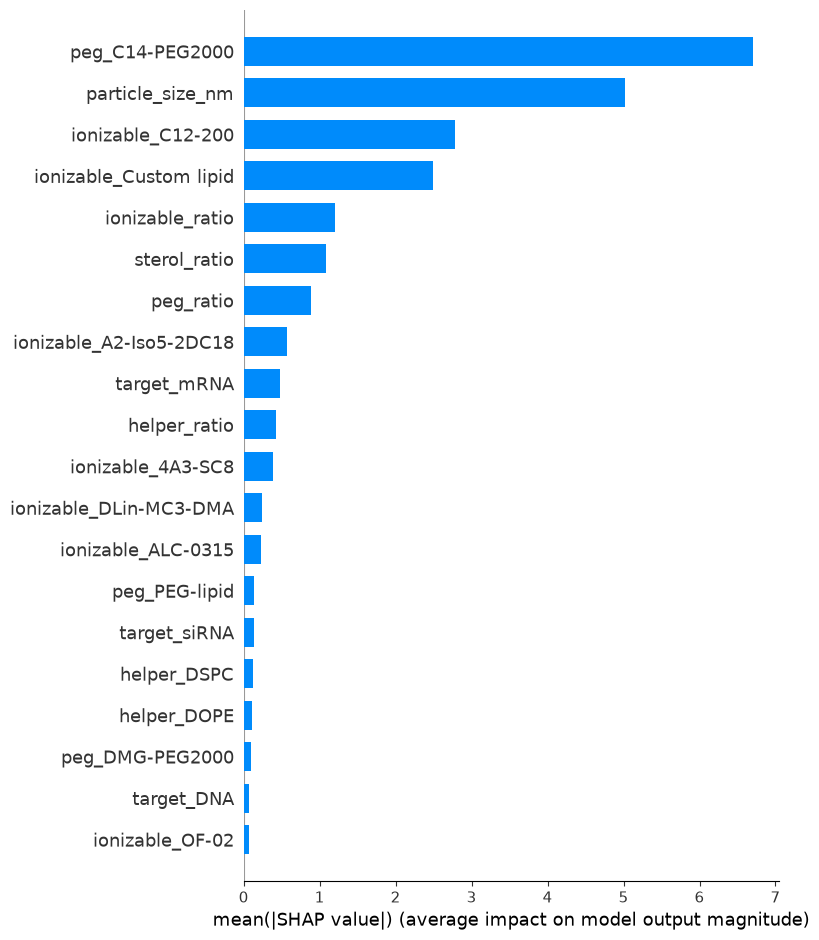

--- Directional Impact (Beeswarm) ---


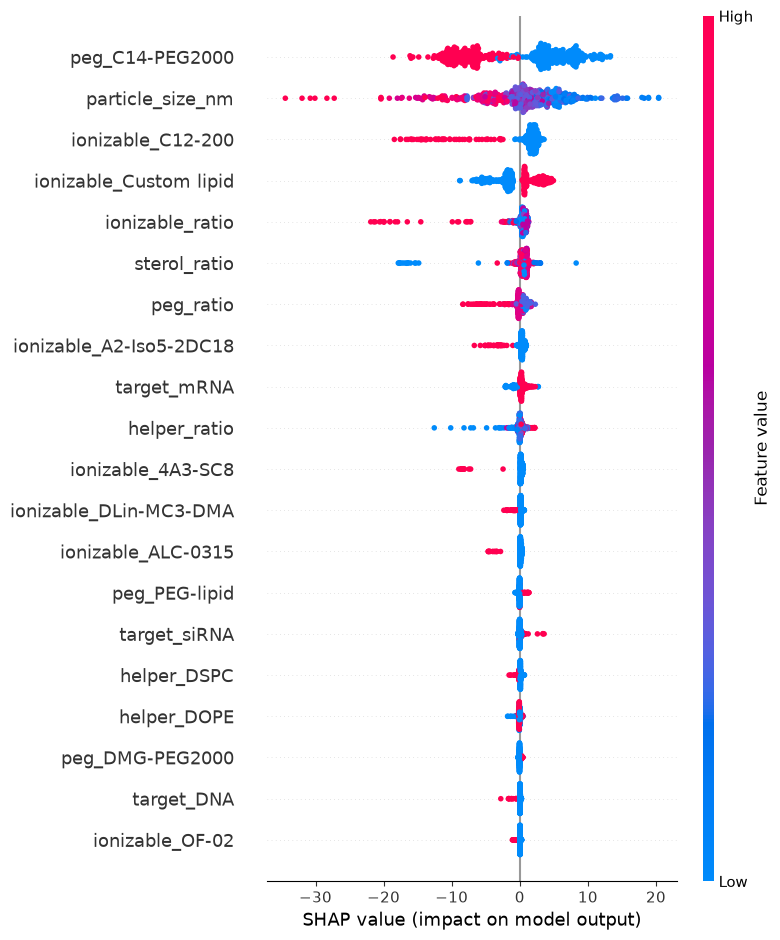

In [1]:
import shap
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor

# 1. Load the dataset
path_adv = "../data/processed/df_final_all_features.csv"
df_adv = pd.read_csv(path_adv)
X_adv = df_adv.drop(columns=["encapsulation_efficiency"])
y_adv = df_adv["encapsulation_efficiency"]

# 2. Train the Champion Random Forest
champion_rf = RandomForestRegressor(
    n_estimators=100, 
    max_depth=None, 
    min_samples_split=10, 
    random_state=42
)
champion_rf.fit(X_adv, y_adv)

# 3. Initialize the SHAP Explainer
# TreeExplainer is extremely fast and mathematically exact for Random Forests
explainer = shap.TreeExplainer(champion_rf)
shap_values = explainer.shap_values(X_adv)

# 4. Generate the Plots
print("--- Global Feature Importance ---")
shap.summary_plot(shap_values, X_adv, plot_type="bar", show=False)
plt.show()

print("--- Directional Impact (Beeswarm) ---")
shap.summary_plot(shap_values, X_adv, show=False)
plt.show()

## Observations - Feature Importance

To understand the chemical logic driving the Champion Random Forest, SHAP (SHapley Additive exPlanations) values were calculated. The global feature importance bar plot ranks the absolute impact of each parameter, while the beeswarm plot maps the directional effect of these features on the predicted encapsulation efficiency.

**Key Formulation Insights:**

*   **PEG Lipid Selection:** The choice of PEG lipid is the most influential variable in the dataset. Specifically, the presence of `peg_C14-PEG2000` heavily penalizes predicted encapsulation efficiency, dragging SHAP values strictly negative.
*   **Particle Size Dynamics:** There is a definitive inverse relationship between physical size and encapsulation. Larger LNP diameters (red) consistently reduce predicted efficiency, whereas smaller particles (blue) drive predictions upward.
*   **Ionizable Lipid Chemistry:** The model heavily favors proprietary or optimized chemistry. Using a `Custom lipid` yields a distinct positive impact on encapsulation, whereas older generation standard lipids like `C12-200` drag efficiency down.
*   **Structural Ratio Thresholds:** 
    *   **Sterol Ratio:** Formulations lacking sufficient sterol (deep blue) face a harsh negative penalty, indicating a hard baseline requirement for vesicle stability.
    *   **PEG & Ionizable Ratios:** High concentrations of these components (red) actively harm encapsulation, pointing to an oversaturation limit in the formulation process.

# Neural Network model

#TO DO